# GLIME 08: STL-10 Gaussian-Noise LIME (airplane target extension)

This notebook is a **fresh experiment notebook** built on top of the STL-10 work from folder `05`.

The goal here is **not** to retrain the model.  
Instead, this notebook focuses on controlled explanation experiments:

- slimmer segmentation boundaries
- Gaussian-noise LIME with **green for positive** and **red for negative** contributions
- a broad **noise intensity sweep**
- a broad **distance-weight / locality-weight sweep**
- a comparison of **different weighting functions**

## Important note about retraining

This notebook expects a saved checkpoint from the model in `05`, for example:

```python
torch.save(best_state, "05/stl10_best_model.pt")
```

If that file does not exist, the notebook will stop with a clear message rather than retraining.

If you still have the old `05` kernel alive somewhere, you can save that checkpoint once without retraining and then use this notebook for all experiments.


This notebook extends `glime_07.ipynb` and keeps the same pipeline while forcing explanations for the **airplane hypothesis** (the second-highest class for the selected ship image).


In [18]:
# =========================
# 0. Imports
# =========================

import math
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from lime import lime_image
from skimage.segmentation import slic, mark_boundaries


In [19]:
# =========================
# 1. Setup
# =========================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

class_names = [
    "airplane", "bird", "car", "cat", "deer",
    "dog", "horse", "monkey", "ship", "truck"
]

num_classes = len(class_names)
data_root = "./data"
checkpoint_path = Path("stl10_best_model.pt")

print("Checkpoint path:", checkpoint_path.resolve())


Device: cpu
Checkpoint path: /Users/seyidaniel/Desktop/research_folder/code/glime_github/glime/stl10_best_model.pt


## Checkpoint policy

This notebook deliberately avoids training code.

- If the checkpoint exists, we load it and continue.
- If it does not exist, we stop and explain why.

That keeps all the work here focused on explanation experiments only.


In [20]:
# =========================
# 2. Re-create the STL-10 model architecture
# =========================

class ImprovedSTL10CNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((3, 3)),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 3 * 3, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = ImprovedSTL10CNN(num_classes=num_classes).to(device)
print(model.__class__.__name__)


ImprovedSTL10CNN


In [21]:
# =========================
# 3. Load checkpoint without retraining
# =========================

if not checkpoint_path.exists():
    raise FileNotFoundError(
        "Checkpoint not found. This notebook does not retrain the model. "
        "Please save the trained state from folder 05 once, for example with "
        "torch.save(best_state, '05/stl10_best_model.pt'), and then rerun this notebook."
    )

state_dict = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(state_dict)
model.eval()

print("Checkpoint loaded successfully.")


Checkpoint loaded successfully.


In [22]:
# =========================
# 4. Load STL-10 test data
# =========================

eval_transform = transforms.Compose([
    transforms.ToTensor(),
])

test_dataset = datasets.STL10(
    root=data_root,
    split="test",
    download=True,
    transform=eval_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=2
)

print("Test examples:", len(test_dataset))


Files already downloaded and verified
Test examples: 8000


In [23]:
# =========================
# 5. Prediction wrapper for LIME
# =========================

def predict_fn(images):
    """
    LIME provides images as NumPy arrays in HWC format.
    This wrapper converts them into PyTorch tensors and returns
    class probabilities.
    """

    model.eval()

    images = np.array(images).astype(np.float32)

    if images.max() > 1.0:
        images = images / 255.0

    images = torch.tensor(images).permute(0, 3, 1, 2).float().to(device)

    with torch.no_grad():
        logits = model(images)
        probs = F.softmax(logits, dim=1)

    return probs.cpu().numpy()


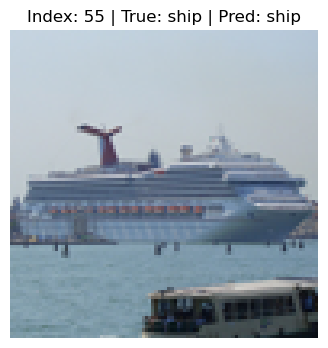

Top 1: ship -> 0.5957
Top 2: airplane -> 0.4028
Top 3: truck -> 0.0011


In [24]:
# =========================
# 6. Pick a correctly classified example
# =========================

def find_correct_example(dataset, desired_label=None):
    """
    Use a correctly classified image so that the explanation reflects
    a successful prediction rather than a mistake.

    If desired_label is provided, the search tries to find a correct
    example from that class first.
    """

    model.eval()

    for idx in range(len(dataset)):
        image_tensor, label = dataset[idx]

        if desired_label is not None and label != desired_label:
            continue

        image_uint8 = (image_tensor.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
        probs = predict_fn(np.array([image_uint8]))[0]
        pred = int(np.argmax(probs))

        if pred == label:
            return idx, image_tensor, label, probs

    for idx in range(len(dataset)):
        image_tensor, label = dataset[idx]
        image_uint8 = (image_tensor.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
        probs = predict_fn(np.array([image_uint8]))[0]
        pred = int(np.argmax(probs))

        if pred == label:
            return idx, image_tensor, label, probs

    raise RuntimeError("No correctly classified STL-10 test example was found.")


example_idx, image_tensor, true_label, probs = find_correct_example(test_dataset, desired_label=8)

image = image_tensor.permute(1, 2, 0).numpy()
image_uint8 = (image * 255).astype(np.uint8)
pred_label = int(np.argmax(probs))

plt.figure(figsize=(4, 4))
plt.imshow(image_uint8)
plt.title(
    f"Index: {example_idx} | True: {class_names[true_label]} | "
    f"Pred: {class_names[pred_label]}"
)
plt.axis("off")
plt.show()

top3_indices = np.argsort(probs)[-3:][::-1]
for rank, class_index in enumerate(top3_indices, start=1):
    print(f"Top {rank}: {class_names[class_index]} -> {probs[class_index]:.4f}")

explained_class = int(top3_indices[1])
print("
Predicted class (top-1):", class_names[pred_label])
print("Explanation target for GLIME 08 (top-2):", class_names[explained_class])


## Slimmer segmentation boundaries

The old notebook used thick segmentation boundaries.

Here we switch to a **slimmer boundary style** so the image content stays more visible.  
The segmentation itself still comes from SLIC, but the rendering is lighter and less bulky.


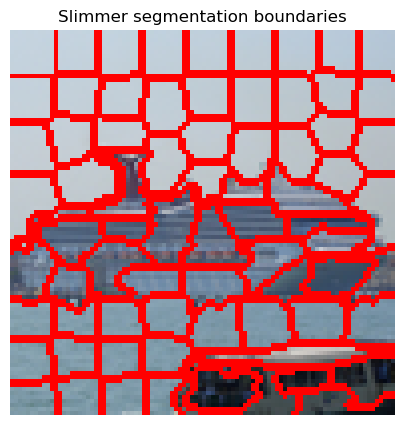

Number of segments: 75


In [25]:
# =========================
# 7. Segmentation with slimmer boundaries
# =========================

def segmentation_fn(image, n_segments=70, compactness=12, sigma=1):
    return slic(
        image,
        n_segments=n_segments,
        compactness=compactness,
        sigma=sigma,
        start_label=0
    )


segments = segmentation_fn(image_uint8)

plt.figure(figsize=(5, 5))
plt.imshow(
    mark_boundaries(
        image_uint8 / 255.0,
        segments,
        color=(1, 0, 0),
        mode="inner"
    )
)
plt.title("Slimmer segmentation boundaries")
plt.axis("off")
plt.show()

print("Number of segments:", len(np.unique(segments)))


  0%|          | 0/1000 [00:00<?, ?it/s]

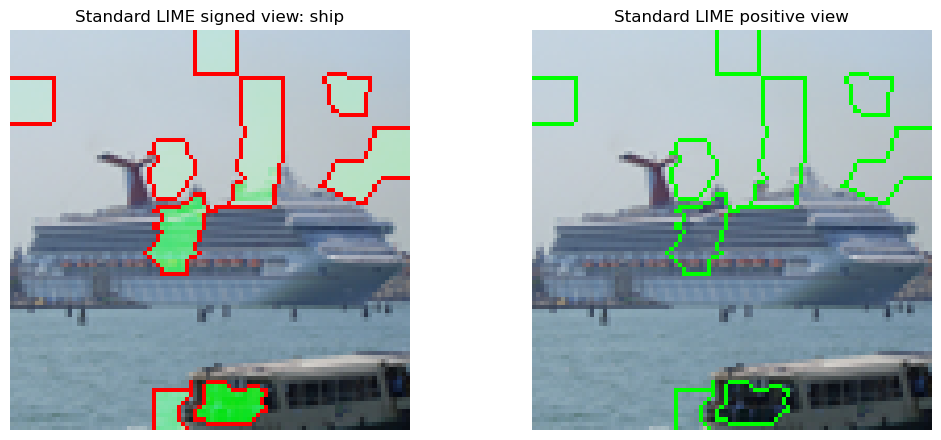

In [26]:
# =========================
# 8. Standard LIME with slimmer boundaries
# =========================

explainer = lime_image.LimeImageExplainer(random_state=42)

standard_explanation = explainer.explain_instance(
    image_uint8,
    predict_fn,
    top_labels=1,
    hide_color=0,
    num_samples=1000,
    segmentation_fn=segmentation_fn
)

standard_label = standard_explanation.top_labels[0]

temp_signed, mask_signed = standard_explanation.get_image_and_mask(
    standard_label,
    positive_only=False,
    num_features=12,
    hide_rest=False
)

temp_pos, mask_pos = standard_explanation.get_image_and_mask(
    standard_label,
    positive_only=True,
    num_features=12,
    hide_rest=False
)

plt.figure(figsize=(11, 4.5))

plt.subplot(1, 2, 1)
plt.imshow(mark_boundaries(temp_signed / 255.0, mask_signed, color=(1, 0, 0), mode="inner"))
plt.title(f"Standard LIME signed view: {class_names[standard_label]}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mark_boundaries(temp_pos / 255.0, mask_pos, color=(0, 1, 0), mode="inner"))
plt.title("Standard LIME positive view")
plt.axis("off")

plt.tight_layout()
plt.show()


## Gaussian-noise LIME with signed colors

For the Gaussian-noise version, the notebook now uses the same intuitive sign convention you asked for:

- **green** = positive contribution
- **red** = negative contribution

This replaces the old blue-yellow continuous heatmap with a signed explanation view.


In [27]:
# =========================
# 9. Gaussian-noise perturbation
# =========================

def perturb_with_noise(image, segments, mask, sigma_noise=30):
    """
    mask[i] = 1 means keep the segment unchanged
    mask[i] = 0 means corrupt the segment with Gaussian noise
    """

    perturbed = image.astype(np.float32).copy()
    unique_segments = np.unique(segments)

    noise = np.random.normal(
        loc=0,
        scale=sigma_noise,
        size=image.shape
    )

    for i, seg_val in enumerate(unique_segments):
        if mask[i] == 0:
            region = segments == seg_val
            perturbed[region] += noise[region]

    return np.clip(perturbed, 0, 255).astype(np.uint8)


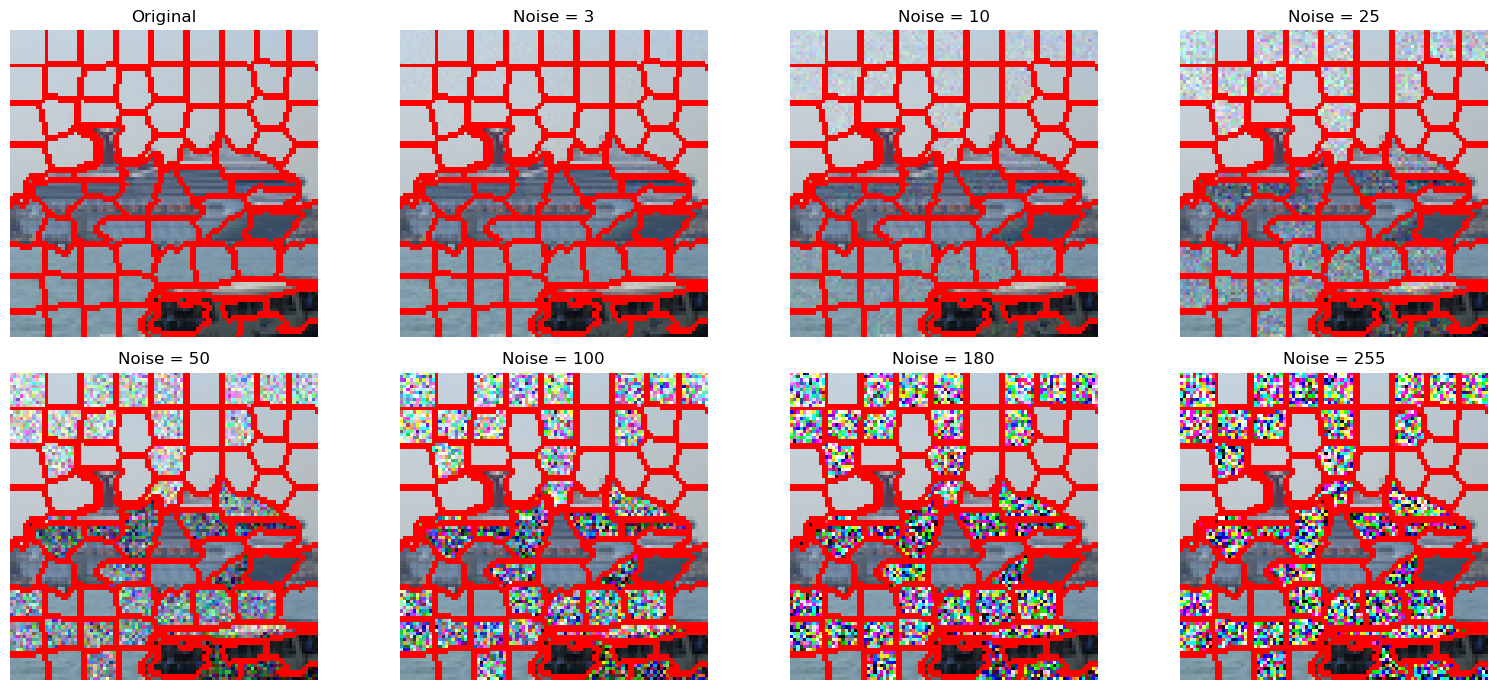

In [28]:
# =========================
# 10. Example perturbations across a wide noise range
# =========================

# This range goes from extremely light noise to very aggressive corruption.
noise_values_demo = [3, 10, 25, 50, 100, 180, 255]

num_segments = len(np.unique(segments))
shared_demo_mask = np.random.randint(0, 2, num_segments)

fig, axes = plt.subplots(2, math.ceil((len(noise_values_demo) + 1) / 2), figsize=(16, 7))
axes = axes.flatten()

axes[0].imshow(mark_boundaries(image_uint8 / 255.0, segments, color=(1, 0, 0), mode="inner"))
axes[0].set_title("Original")
axes[0].axis("off")

for plot_idx, sigma_noise in enumerate(noise_values_demo, start=1):
    perturbed = perturb_with_noise(
        image_uint8,
        segments,
        shared_demo_mask,
        sigma_noise=sigma_noise
    )
    axes[plot_idx].imshow(mark_boundaries(perturbed / 255.0, segments, color=(1, 0, 0), mode="inner"))
    axes[plot_idx].set_title(f"Noise = {sigma_noise}")
    axes[plot_idx].axis("off")

for extra_ax in axes[len(noise_values_demo) + 1:]:
    extra_ax.axis("off")

plt.tight_layout()
plt.show()


In [29]:
# =========================
# 11. Locality weighting (default LIME kernel)
# =========================

def compute_sample_weight(distance, kernel_width):
    """Default LIME kernel: exp(-(d^2)/(kernel_width^2))."""
    return np.exp(-(distance ** 2) / (kernel_width ** 2))


In [30]:
# =========================
# 12. Gaussian-noise LIME experiment engine
# =========================

def default_kernel_width(num_segments):
    """Default LIME kernel width: 0.75 * sqrt(D), where D is #interpretable features."""
    return 0.75 * np.sqrt(num_segments)

def gaussian_noise_lime(
    image,
    num_samples=1000,
    sigma_noise=35,
    kernel_width=None,
    target_class=None,
):
    """
    Create a local explanation dataset around one image using noisy
    perturbations, then fit a one-weight-per-segment surrogate model.
    """

    segments = segmentation_fn(image)
    unique_segments = np.unique(segments)
    num_segments = len(unique_segments)

    if kernel_width is None:
        kernel_width = default_kernel_width(num_segments)

    data = []
    preds = []
    sample_weights = []

    for _ in range(num_samples):
        mask = np.random.randint(0, 2, num_segments)

        perturbed = perturb_with_noise(
            image,
            segments,
            mask,
            sigma_noise=sigma_noise
        )

        pred = predict_fn(np.array([perturbed]))[0]
        distance = np.sum(mask == 0)
        weight = compute_sample_weight(distance, kernel_width=kernel_width)

        data.append(mask)
        preds.append(pred)
        sample_weights.append(weight)

    data = np.array(data)
    preds = np.array(preds)
    sample_weights = np.array(sample_weights)

    if target_class is None:
        target_class = int(np.argmax(predict_fn(np.array([image]))[0]))
    y = preds[:, target_class]

    X = np.concatenate([data, np.ones((data.shape[0], 1))], axis=1)
    W = sample_weights[:, None]

    # Weighted least squares gives one surrogate coefficient per segment.
    XtWX = X.T @ (W * X)
    XtWy = X.T @ (sample_weights * y)
    coefficients = np.linalg.pinv(XtWX) @ XtWy
    segment_weights = coefficients[:-1]

    return {
        "segments": segments,
        "target_class": target_class,
        "segment_weights": segment_weights,
        "sample_weights": sample_weights,
        "preds": preds,
        "data": data,
        "sigma_noise": sigma_noise,
        "kernel_width": kernel_width,
    }


In [31]:
# =========================
# 13. Signed Gaussian-noise visualization
# =========================

def build_signed_maps(segments, segment_weights):
    """
    Build separate positive and negative maps so we can show:
    - green for supporting regions
    - red for opposing regions
    """

    positive_map = np.zeros(segments.shape, dtype=np.float32)
    negative_map = np.zeros(segments.shape, dtype=np.float32)

    for i, seg_val in enumerate(np.unique(segments)):
        weight = segment_weights[i]
        if weight > 0:
            positive_map[segments == seg_val] = weight
        elif weight < 0:
            negative_map[segments == seg_val] = abs(weight)

    if positive_map.max() > 0:
        positive_map = positive_map / positive_map.max()

    if negative_map.max() > 0:
        negative_map = negative_map / negative_map.max()

    return positive_map, negative_map


def show_signed_gaussian_explanation(image_uint8, result, title):
    positive_map, negative_map = build_signed_maps(
        result["segments"],
        result["segment_weights"]
    )

    plt.figure(figsize=(6, 6))
    plt.imshow(image_uint8)

    # Green = positive contribution
    green_overlay = np.zeros((*positive_map.shape, 4), dtype=np.float32)
    green_overlay[..., 1] = 1.0
    green_overlay[..., 3] = 0.65 * positive_map

    # Red = negative contribution
    red_overlay = np.zeros((*negative_map.shape, 4), dtype=np.float32)
    red_overlay[..., 0] = 1.0
    red_overlay[..., 3] = 0.65 * negative_map

    plt.imshow(green_overlay)
    plt.imshow(red_overlay)
    plt.imshow(
        mark_boundaries(
            np.zeros_like(image_uint8) / 255.0,
            result["segments"],
            color=(1, 1, 1),
            mode="inner"
        ),
        alpha=0.35
    )

    legend_handles = [
        Patch(facecolor=(0, 1, 0, 0.6), edgecolor="none", label="Positive / supports class"),
        Patch(facecolor=(1, 0, 0, 0.6), edgecolor="none", label="Negative / opposes class"),
    ]
    plt.legend(handles=legend_handles, loc="lower left")
    plt.title(title)
    plt.axis("off")
    plt.show()


Target class: ship
Kernel width (0.75*sqrt(D)): 6.4952


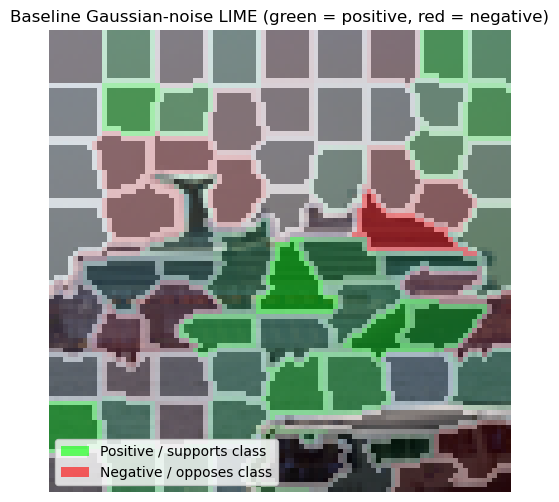

In [32]:
# =========================
# 14. Baseline Gaussian-noise explanation
# =========================

baseline_result = gaussian_noise_lime(
    image_uint8,
    num_samples=1000,
    sigma_noise=35,
    target_class=explained_class
)

print("Target class:", class_names[baseline_result["target_class"]])
print("Kernel width (0.75*sqrt(D)):", round(baseline_result["kernel_width"], 4))
show_signed_gaussian_explanation(
    image_uint8,
    baseline_result,
    f"Baseline Gaussian-noise LIME for {class_names[explained_class]} (green = positive, red = negative)"
)


## Experiment 1: Noise intensity sweep

This experiment keeps the weighting logic fixed and changes only the **noise intensity**.

The range goes from very small perturbations to extremely aggressive ones so you can see how stable or unstable the explanation is as the corrupted regions become more severe.


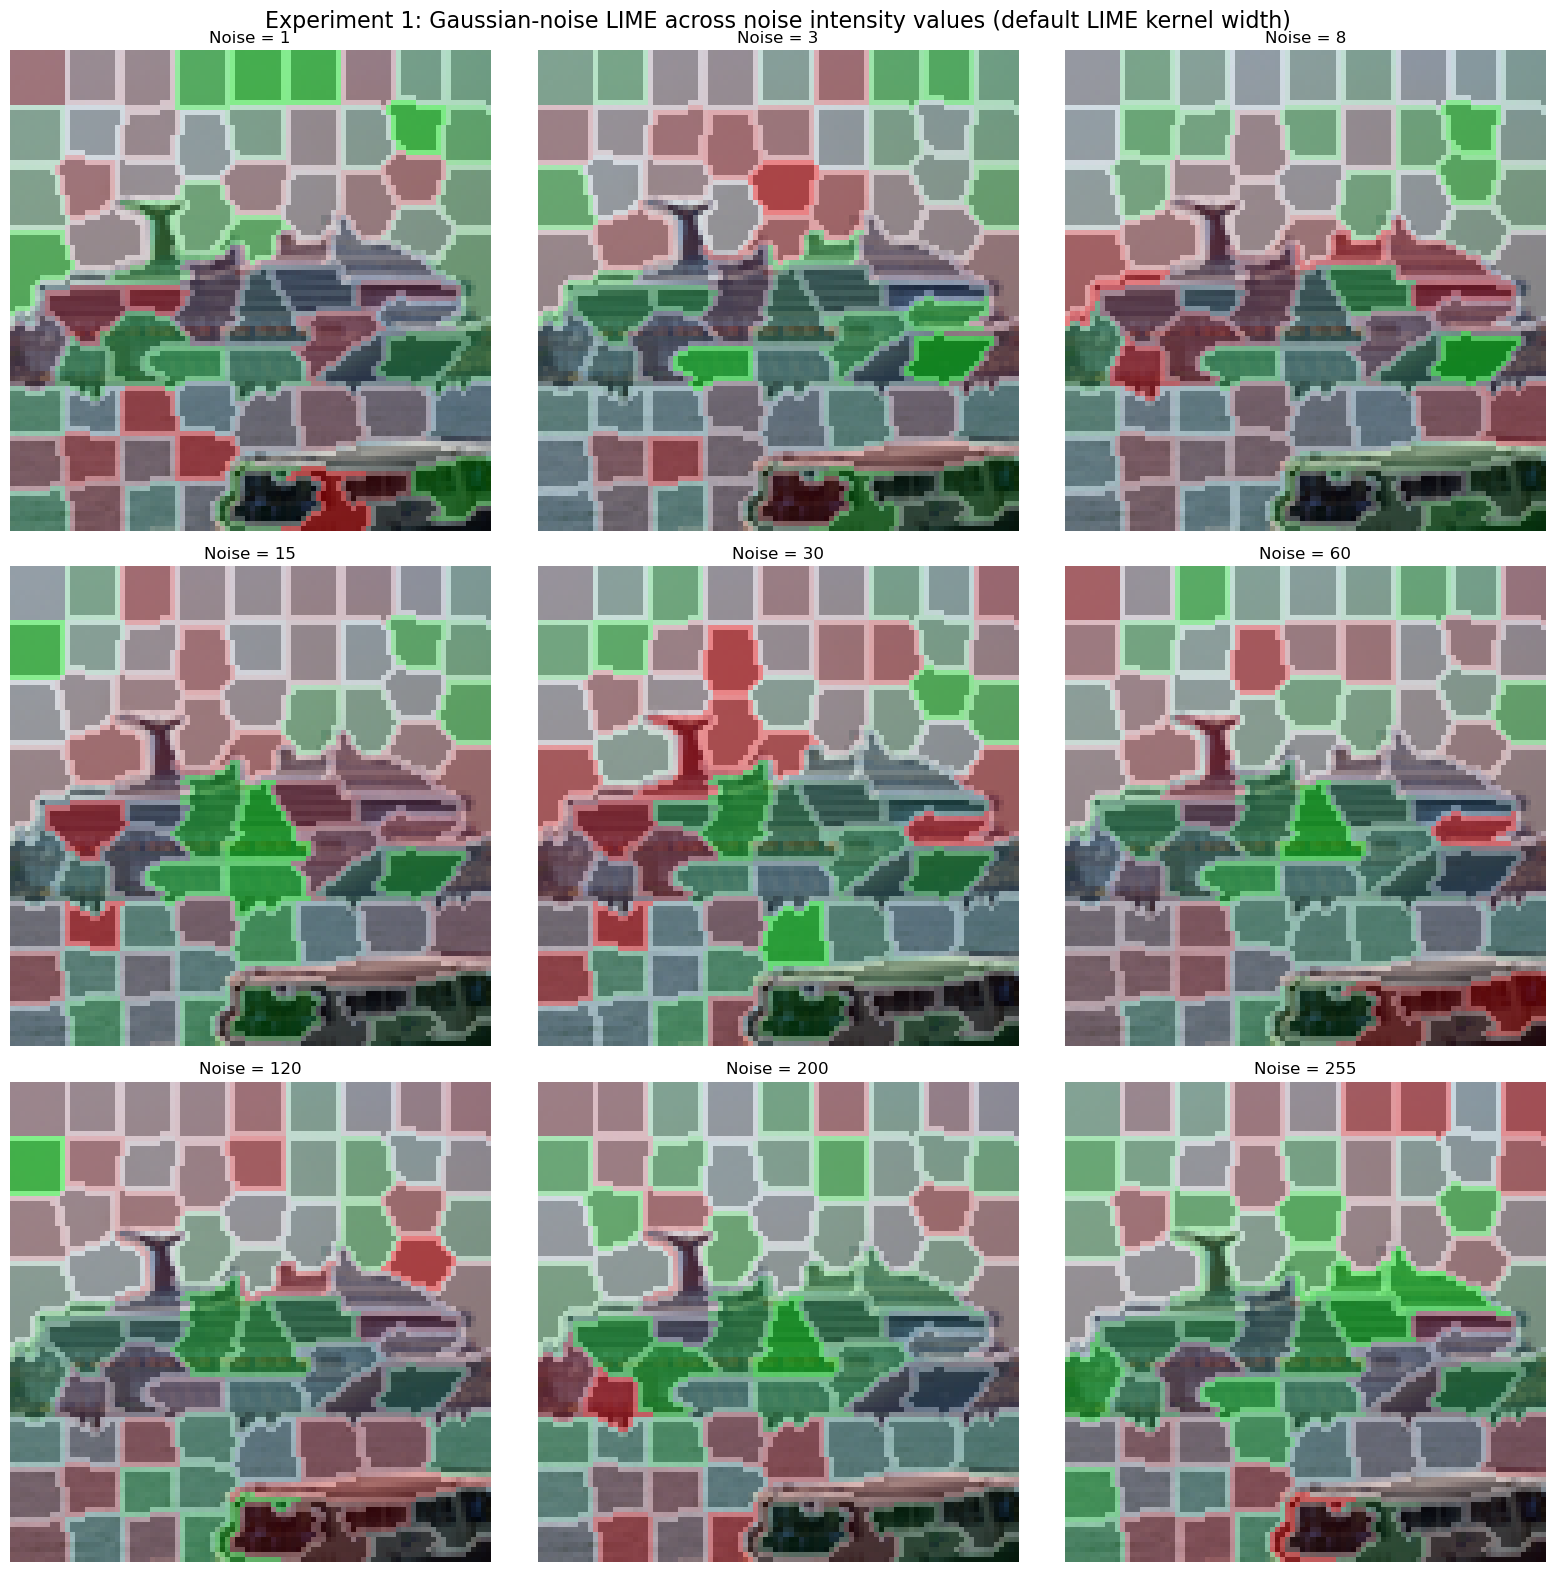

In [33]:
# =========================
# 15. Experiment 1: sweep noise intensity
# =========================

noise_values = [1, 3, 8, 15, 30, 60, 120, 200, 255]

fig, axes = plt.subplots(3, 3, figsize=(16, 16))
axes = axes.flatten()

for ax, sigma_noise in zip(axes, noise_values):
    result = gaussian_noise_lime(
        image_uint8,
        num_samples=1000,
        sigma_noise=sigma_noise,
        target_class=explained_class
    )

    pos_map, neg_map = build_signed_maps(result["segments"], result["segment_weights"])

    ax.imshow(image_uint8)

    green_overlay = np.zeros((*pos_map.shape, 4), dtype=np.float32)
    green_overlay[..., 1] = 1.0
    green_overlay[..., 3] = 0.55 * pos_map

    red_overlay = np.zeros((*neg_map.shape, 4), dtype=np.float32)
    red_overlay[..., 0] = 1.0
    red_overlay[..., 3] = 0.55 * neg_map

    ax.imshow(green_overlay)
    ax.imshow(red_overlay)
    ax.imshow(
        mark_boundaries(
            np.zeros_like(image_uint8) / 255.0,
            result["segments"],
            color=(1, 1, 1),
            mode="inner"
        ),
        alpha=0.25
    )
    ax.set_title(f"Noise = {sigma_noise}")
    ax.axis("off")

plt.suptitle("Experiment 1: Gaussian-noise LIME across noise intensity values (default LIME kernel width)", fontsize=16)
plt.tight_layout()
plt.show()


In [34]:
# =========================
# 16. Optional focused single-run helper
# =========================

def run_single_experiment(
    sigma_noise=35,
    kernel_width=None,
    num_samples=1000
):
    result = gaussian_noise_lime(
        image_uint8,
        num_samples=num_samples,
        sigma_noise=sigma_noise,
        kernel_width=kernel_width,
        target_class=explained_class
    )

    print("Target class:", class_names[result["target_class"]])
    print("Noise intensity:", sigma_noise)
    print("Kernel width:", result["kernel_width"])

    show_signed_gaussian_explanation(
        image_uint8,
        result,
        (
            "Single experiment | "
            f"noise={sigma_noise}, kernel={result['kernel_width']:.3f}"
        )
    )

    return result


## Experiment 2: Kernel-width sweep for airplane target

This keeps noise fixed and changes locality width to see how sensitive the **airplane (top-2) explanation** is to neighborhood weighting.


In [ ]:
# =========================
# 17. Experiment 2: sweep kernel width (airplane target)
# =========================

num_segments = len(np.unique(segments))
default_kw = default_kernel_width(num_segments)
kernel_values = [
    0.25 * default_kw,
    0.5 * default_kw,
    0.75 * default_kw,
    1.0 * default_kw,
    1.5 * default_kw,
    2.0 * default_kw,
]

fig, axes = plt.subplots(2, 3, figsize=(17, 11))
axes = axes.flatten()

for ax, kw in zip(axes, kernel_values):
    result = gaussian_noise_lime(
        image_uint8,
        num_samples=1000,
        sigma_noise=35,
        kernel_width=kw,
        target_class=explained_class
    )

    pos_map, neg_map = build_signed_maps(result["segments"], result["segment_weights"])

    ax.imshow(image_uint8)

    green_overlay = np.zeros((*pos_map.shape, 4), dtype=np.float32)
    green_overlay[..., 1] = 1.0
    green_overlay[..., 3] = 0.55 * pos_map

    red_overlay = np.zeros((*neg_map.shape, 4), dtype=np.float32)
    red_overlay[..., 0] = 1.0
    red_overlay[..., 3] = 0.55 * neg_map

    ax.imshow(green_overlay)
    ax.imshow(red_overlay)

    ax.set_title(f"kernel={kw:.2f}")
    ax.axis("off")

plt.suptitle(f"Kernel sweep for target class: {class_names[explained_class]}", y=0.98)
plt.tight_layout()
plt.show()


## Suggested interpretation prompts

As you look across the experiments, useful questions include:

1. Which regions stay green no matter how the noise intensity changes?
2. At what noise level do the explanations become unstable or noisy themselves?
3. Do small distance kernels focus more tightly on the object than large kernels?
4. Which weighting function produces the clearest object-centered explanation?
5. Are negative regions mostly background, borders, or semantically meaningful object parts?
